In [1]:
#Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Datasets
apps_df = pd.read_csv(r"C:\Users\user\Downloads\archive (2)\googleplaystore.csv")
reviews_df = pd.read_csv(r"C:\Users\user\Downloads\archive (2)\googleplaystore_user_reviews.csv")

In [3]:
# Step 2: Initial Data Exploration
# Apps Dataset
print("🗂️ Apps Dataset Overview:")
print("Shape:", apps_df.shape)
print("Columns:", apps_df.columns.tolist())
print("\nFirst 5 Rows:\n", apps_df.head())
print("\nLast 5 Rows:\n", apps_df.tail())
print("\nData Types & Null Values:\n")
print(apps_df.info())
print("\nDescriptive Statistics:\n", apps_df.describe(include='all'))
print("\nMissing Values (per column):\n", apps_df.isnull().sum())
print("\nUnique Categories:", apps_df['Category'].nunique())
print("Top 5 Categories:\n", apps_df['Category'].value_counts().head())


🗂️ Apps Dataset Overview:
Shape: (10841, 13)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

First 5 Rows:
                                                  App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4 

In [4]:
# Reviews Datase
print("\n Reviews Dataset Overview:")
print("Shape:", reviews_df.shape)
print("Columns:", reviews_df.columns.tolist())
print("\nFirst 5 Rows:\n", reviews_df.head())
print("\nMissing Values (per column):\n", reviews_df.isnull().sum())
print("Unique Sentiments:", reviews_df['Sentiment'].unique())
print("Sentiment Distribution:\n", reviews_df['Sentiment'].value_counts())



 Reviews Dataset Overview:
Shape: (64295, 5)
Columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

First 5 Rows:
                      App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  

Missing Values 

In [5]:
# Data Cleaning and Preprocessing
# Drop rows with missing essential values
apps_df = apps_df.dropna(subset=['App', 'Category', 'Reviews'])


In [6]:
# Keep only numeric values in 'Reviews' column
apps_df = apps_df[apps_df['Reviews'].str.isnumeric()]
apps_df['Reviews'] = apps_df['Reviews'].astype(int)


In [7]:
#Keep apps with more than 1000 reviews
apps_df = apps_df[apps_df['Reviews'] > 1000]


In [8]:
# Get Top 5 App Categories
top_categories = apps_df['Category'].value_counts().nlargest(5).index
filtered_apps = apps_df[apps_df['Category'].isin(top_categories)]

print("\n Top 5 Categories with Most Apps:\n", top_categories.tolist())


 Top 5 Categories with Most Apps:
 ['FAMILY', 'GAME', 'TOOLS', 'PHOTOGRAPHY', 'PRODUCTIVITY']


In [9]:
# Merge Apps and User Reviews Data
merged_df = pd.merge(reviews_df, filtered_apps, on='App')


In [10]:
# Drop rows with missing sentiments
merged_df = merged_df.dropna(subset=['Sentiment'])


In [11]:
# Check merged data
print("\n Merged Data Overview:")
print("Shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())
print("Missing Values:\n", merged_df.isnull().sum())



 Merged Data Overview:
Shape: (32241, 17)
Columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Missing Values:
 App                       0
Translated_Review         1
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
Category                  0
Rating                    0
Reviews                   0
Size                      0
Installs                  0
Type                      0
Price                     0
Content Rating            0
Genres                    0
Last Updated              0
Current Ver               0
Android Ver               0
dtype: int64


In [12]:
#  Create Rating Groups
# Function to group ratings
def get_rating_group(rating):
    try:
        rating = float(rating)
        if rating <= 2:
            return '1-2 stars'
        elif 2 < rating <= 4:
            return '3-4 stars'
        elif 4 < rating <= 5:
            return '4-5 stars'
    except:
        return None


In [13]:
# Apply rating group function
merged_df['Rating Group'] = merged_df['Rating'].apply(get_rating_group)
merged_df = merged_df.dropna(subset=['Rating Group'])


In [14]:
# Check value distribution
print("\nRating Group Counts:\n", merged_df['Rating Group'].value_counts())


Rating Group Counts:
 Rating Group
4-5 stars    31158
3-4 stars     1083
Name: count, dtype: int64


In [15]:
#Group and Pivot Sentiment Counts
# ------------------------------
sentiment_counts = merged_df.groupby(
    ['Category', 'Rating Group', 'Sentiment']
).size().reset_index(name='Count')


In [16]:
# Pivot for visualization
pivot_df = sentiment_counts.pivot_table(
    index=['Category', 'Rating Group'],
    columns='Sentiment',
    values='Count',
    fill_value=0
).reset_index()


In [17]:
print("\nPivot Table Sample:\n", pivot_df.head())


Pivot Table Sample:
 Sentiment     Category Rating Group  Negative  Neutral  Positive
0               FAMILY    3-4 stars     120.0     67.0     196.0
1               FAMILY    4-5 stars    1425.0    385.0    3634.0
2                 GAME    3-4 stars      78.0     14.0     124.0
3                 GAME    4-5 stars    7174.0    791.0   10860.0
4          PHOTOGRAPHY    3-4 stars      41.0     17.0      80.0


In [18]:
# 📈 Step 7: Plot Sentiment Distribution
plt.figure(figsize=(14, 8))


<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

In [19]:
# Color mapping
colors = sns.color_palette("Set2", n_colors=3)
sentiment_colors = {'Positive': colors[0], 'Neutral': colors[1], 'Negative': colors[2]}

In [20]:
# Setup for plotting
bar_width = 0.2
categories = pivot_df['Category'].unique()
x_positions = []
x_labels = []

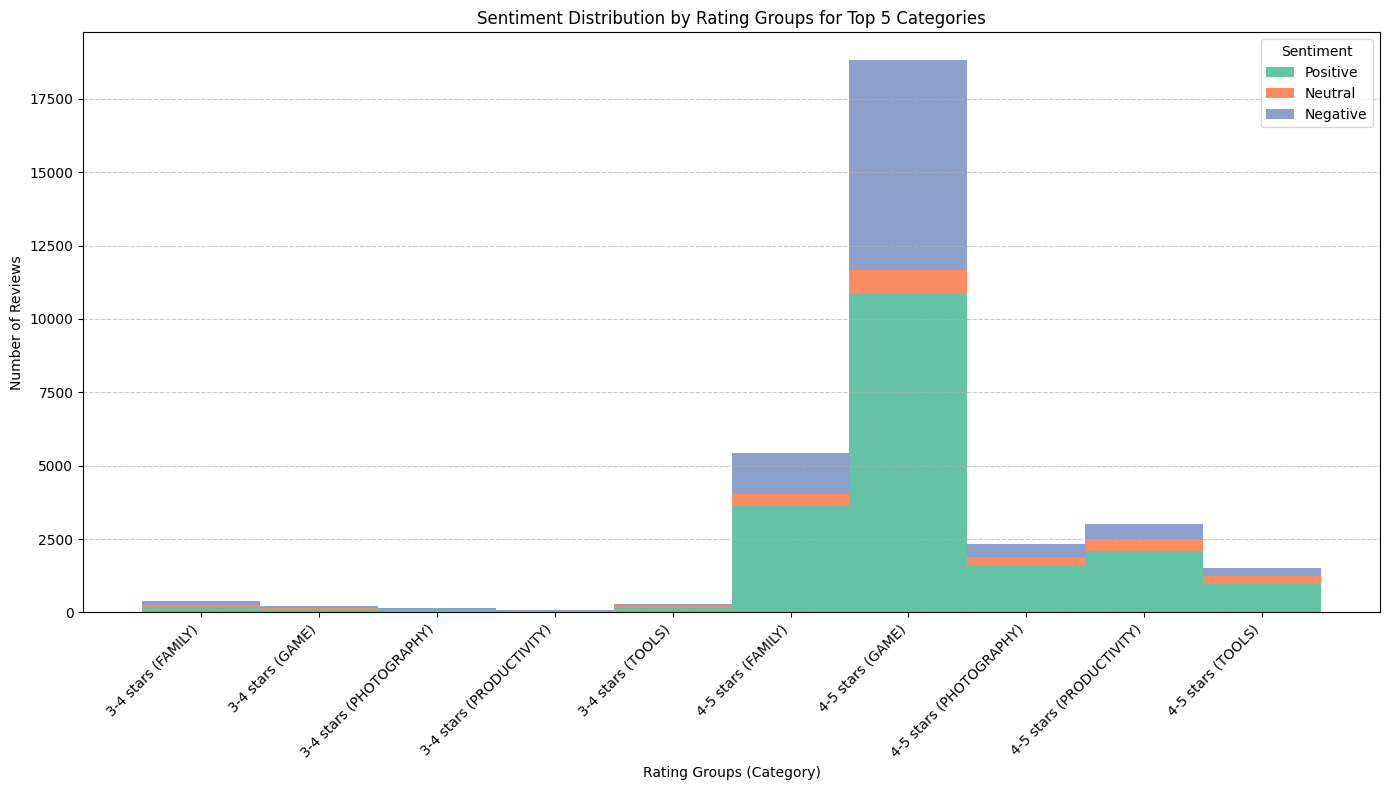

In [23]:
# Check if pivot_df is empty
if pivot_df.empty:
    print(" No data available for the selected filters. Please check your filtering criteria.")
else:
    # Plot by category
    for i, category in enumerate(categories):
        subset = pivot_df[pivot_df['Category'] == category]
        x = range(len(subset['Rating Group']))
        bar_positions = [pos + i * bar_width for pos in x]
        x_positions.extend(bar_positions)
        x_labels.extend([f"{rg} ({category})" for rg in subset['Rating Group']])

        bottom = None
        for sentiment in ['Positive', 'Neutral', 'Negative']:
            if sentiment in subset.columns:
                values = subset[sentiment]
                if values.sum() > 0:  # Ensure there is data to plot
                    plt.bar(
                        bar_positions,
                        values,
                        bottom=bottom,
                        width=bar_width,
                        label=sentiment if i == 0 else "",
                        color=sentiment_colors[sentiment]
                    )
                    bottom = values if bottom is None else bottom + values
 # Plot formatting
    plt.xticks(x_positions, x_labels, rotation=45, ha='right')
    plt.title("Sentiment Distribution by Rating Groups for Top 5 Categories")
    plt.xlabel("Rating Groups (Category)")
    plt.ylabel("Number of Reviews")
    plt.legend(title="Sentiment")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


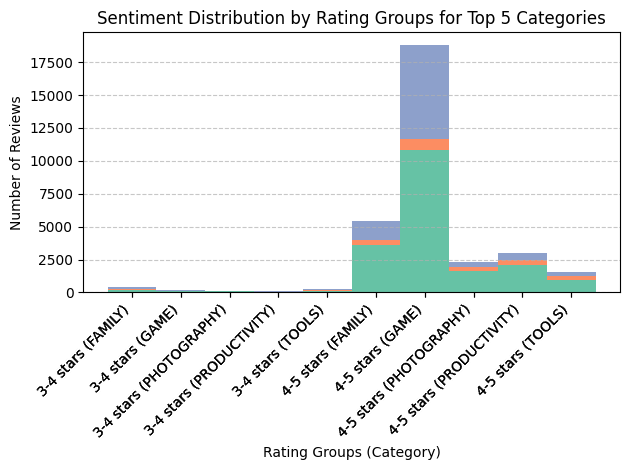

In [24]:
# Plot by category
for i, category in enumerate(categories):
    subset = pivot_df[pivot_df['Category'] == category]
    x = range(len(subset['Rating Group']))
    bar_positions = [pos + i * bar_width for pos in x]
    x_positions.extend(bar_positions)
    x_labels.extend([f"{rg} ({category})" for rg in subset['Rating Group']])

    bottom = None
    for sentiment in ['Positive', 'Neutral', 'Negative']:
        if sentiment in subset.columns:
            values = subset[sentiment]
            plt.bar(
                bar_positions,
                values,
                bottom=bottom,
                width=bar_width,
                label=sentiment if i == 0 else "",
                color=sentiment_colors[sentiment]
            )
            bottom = values if bottom is None else bottom + values

# Plot Formatting (Legend removed)
plt.xticks(x_positions, x_labels, rotation=45, ha='right')
plt.title("Sentiment Distribution by Rating Groups for Top 5 Categories")
plt.xlabel("Rating Groups (Category)")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
